In [30]:
import pandas as pd

srcdir = "E:/SJTU/实习/国泰海通/barra因子/data_base/index/component"
mcpdir = "E:/SJTU/实习/国泰海通/barra因子/data_base/stk_mcp"
retdir = "E:/SJTU/实习/国泰海通/barra因子/data_base/stk_ret"
desdir = "E:/SJTU/实习/国泰海通/barra因子/result/宽基_双创"

df_kj = pd.read_pickle(f"{srcdir}/000300.XSHG_20_26M.pkl")
dates = df_kj.index.get_level_values(0).unique()
mcp_df = pd.read_pickle(f"{mcpdir}/全A_freemcp_20_26M_dict.pkl")
ret_df = pd.read_pickle(f"{retdir}/全A_ret_20_26M_dict.pkl")

target_index = ["000300.XSHG"]#['000300.XSHG','000905.XSHG', '000852.XSHG','932000.INDX','000922.XSHG']
ban_index = ["399006.XSHE"]#["399006.XSHE","000680.XSHG"]
df_kj

weight year_month
date       order_book_id                    
2020-01-23 000001.XSHE    0.01118    2020-01
           000002.XSHE    0.01254    2020-01
           000063.XSHE    0.00691    2020-01
           000069.XSHE    0.00215    2020-01
           000100.XSHE    0.00508    2020-01
...                           ...        ...
2026-03-31 688303.XSHG    0.00056    2026-03
           688396.XSHG    0.00097    2026-03
           688472.XSHG    0.00078    2026-03
           688506.XSHG    0.00094    2026-03
           688981.XSHG    0.00774    2026-03

[22500 rows x 2 columns]

In [47]:
all_combined_data = []
for target in target_index:
    for ban in ban_index:
        ew_ret = {}
        for dt in dates:
        
            date_df = df_kj[df_kj.index.get_level_values(0) == dt].droplevel(0)[["weight"]]

            ban_df = pd.read_pickle(f"{srcdir}/{ban}_20_26M_weights_dict.pkl")
            ban_df = ban_df[dt]

            com_df = date_df.merge(ban_df,on="order_book_id",how="left")
            #com_df = com_df.rename(columns={"weight_x":f"{target}_weight","weight_y":f"{ban}_weight"})
            mcp = mcp_df[dt][["free_mkp"]]
            com_df = com_df.merge(mcp,on="order_book_id",how="left")

            ret = ret_df[dt].droplevel(0)
            com_df = com_df.merge(ret,on="order_book_id",how="left")
            ew_300 = com_df["value"].mean()
            ew_ban = com_df[com_df[f"weight_y"] > 0]["value"].mean()
            ew_minus = ew_300 - ew_ban

            #交付需求1
            overlap_stocks = com_df[(~com_df["weight_x"].isna()) & (~com_df["weight_y"].isna())].copy()
            overlap_stocks.insert(0, 'date', dt)
            
            # 添加target标签
            overlap_stocks['target'] = target
            overlap_stocks['ban'] = ban
            
            # 添加到结果列表
            all_combined_data.append(overlap_stocks)
            ew_ret[dt] = [ew_300,ew_ban,ew_minus]
        ew_df = pd.DataFrame.from_dict(
            ew_ret,
            orient='index',
            columns=['ew_300', 'ew_ban', 'ew_minus']
        )
        #ew_df.index = dates
        ew_df.to_excel(f"{desdir}/{target}_{ban}_ew.xlsx",index=True)
# 把所有target的df全部concat在一起
final_df = pd.concat(all_combined_data)

final_df.rename(columns={"value":"return"},inplace=True)
final_df

,date,weight_x,weight_y,free_mkp,return,target,ban
order_book_id,,,,,,,
300003.XSHE,2020-01-23,0.00253,0.021767,3.086992e+10,-0.027727,000300.XSHG,399006.XSHE
300015.XSHE,2020-01-23,0.00368,0.030986,1.655844e+10,-0.056159,000300.XSHG,399006.XSHE
300017.XSHE,2020-01-23,0.00118,0.009285,1.259853e+10,-0.053118,000300.XSHG,399006.XSHE
300024.XSHE,2020-01-23,0.00123,0.010877,1.575201e+10,-0.006566,000300.XSHG,399006.XSHE
300033.XSHE,2020-01-23,0.00174,0.013189,1.354997e+10,-0.023637,000300.XSHG,399006.XSHE
...,...,...,...,...,...,...,...
300979.XSHE,2026-03-31,0.00031,0.001559,7.879000e+09,-0.002064,000300.XSHG,399006.XSHE
300999.XSHE,2026-03-31,0.00070,0.003077,1.444855e+10,-0.013421,000300.XSHG,399006.XSHE
301236.XSHE,2026-03-31,0.00094,0.004326,2.215476e+10,-0.016262,000300.XSHG,399006.XSHE


In [46]:
ew_df

,ew_300,ew_ban,ew_minus
date,,,
2020-01-23,-0.031283,-0.034474,0.003191
2020-02-28,-0.039388,-0.050228,0.010840
2020-03-31,0.001363,0.000761,0.000603
2020-04-30,0.019407,0.017941,0.001466
2020-05-29,0.004703,0.008694,-0.003991
...,...,...,...
2025-11-28,0.003515,0.005646,-0.002131
2025-12-31,-0.001149,-0.009731,0.008582
2026-01-30,-0.013327,0.002501,-0.015827


C:\Windows\Temp\ipykernel_16656\1027241922.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('nipy_spectral', n)


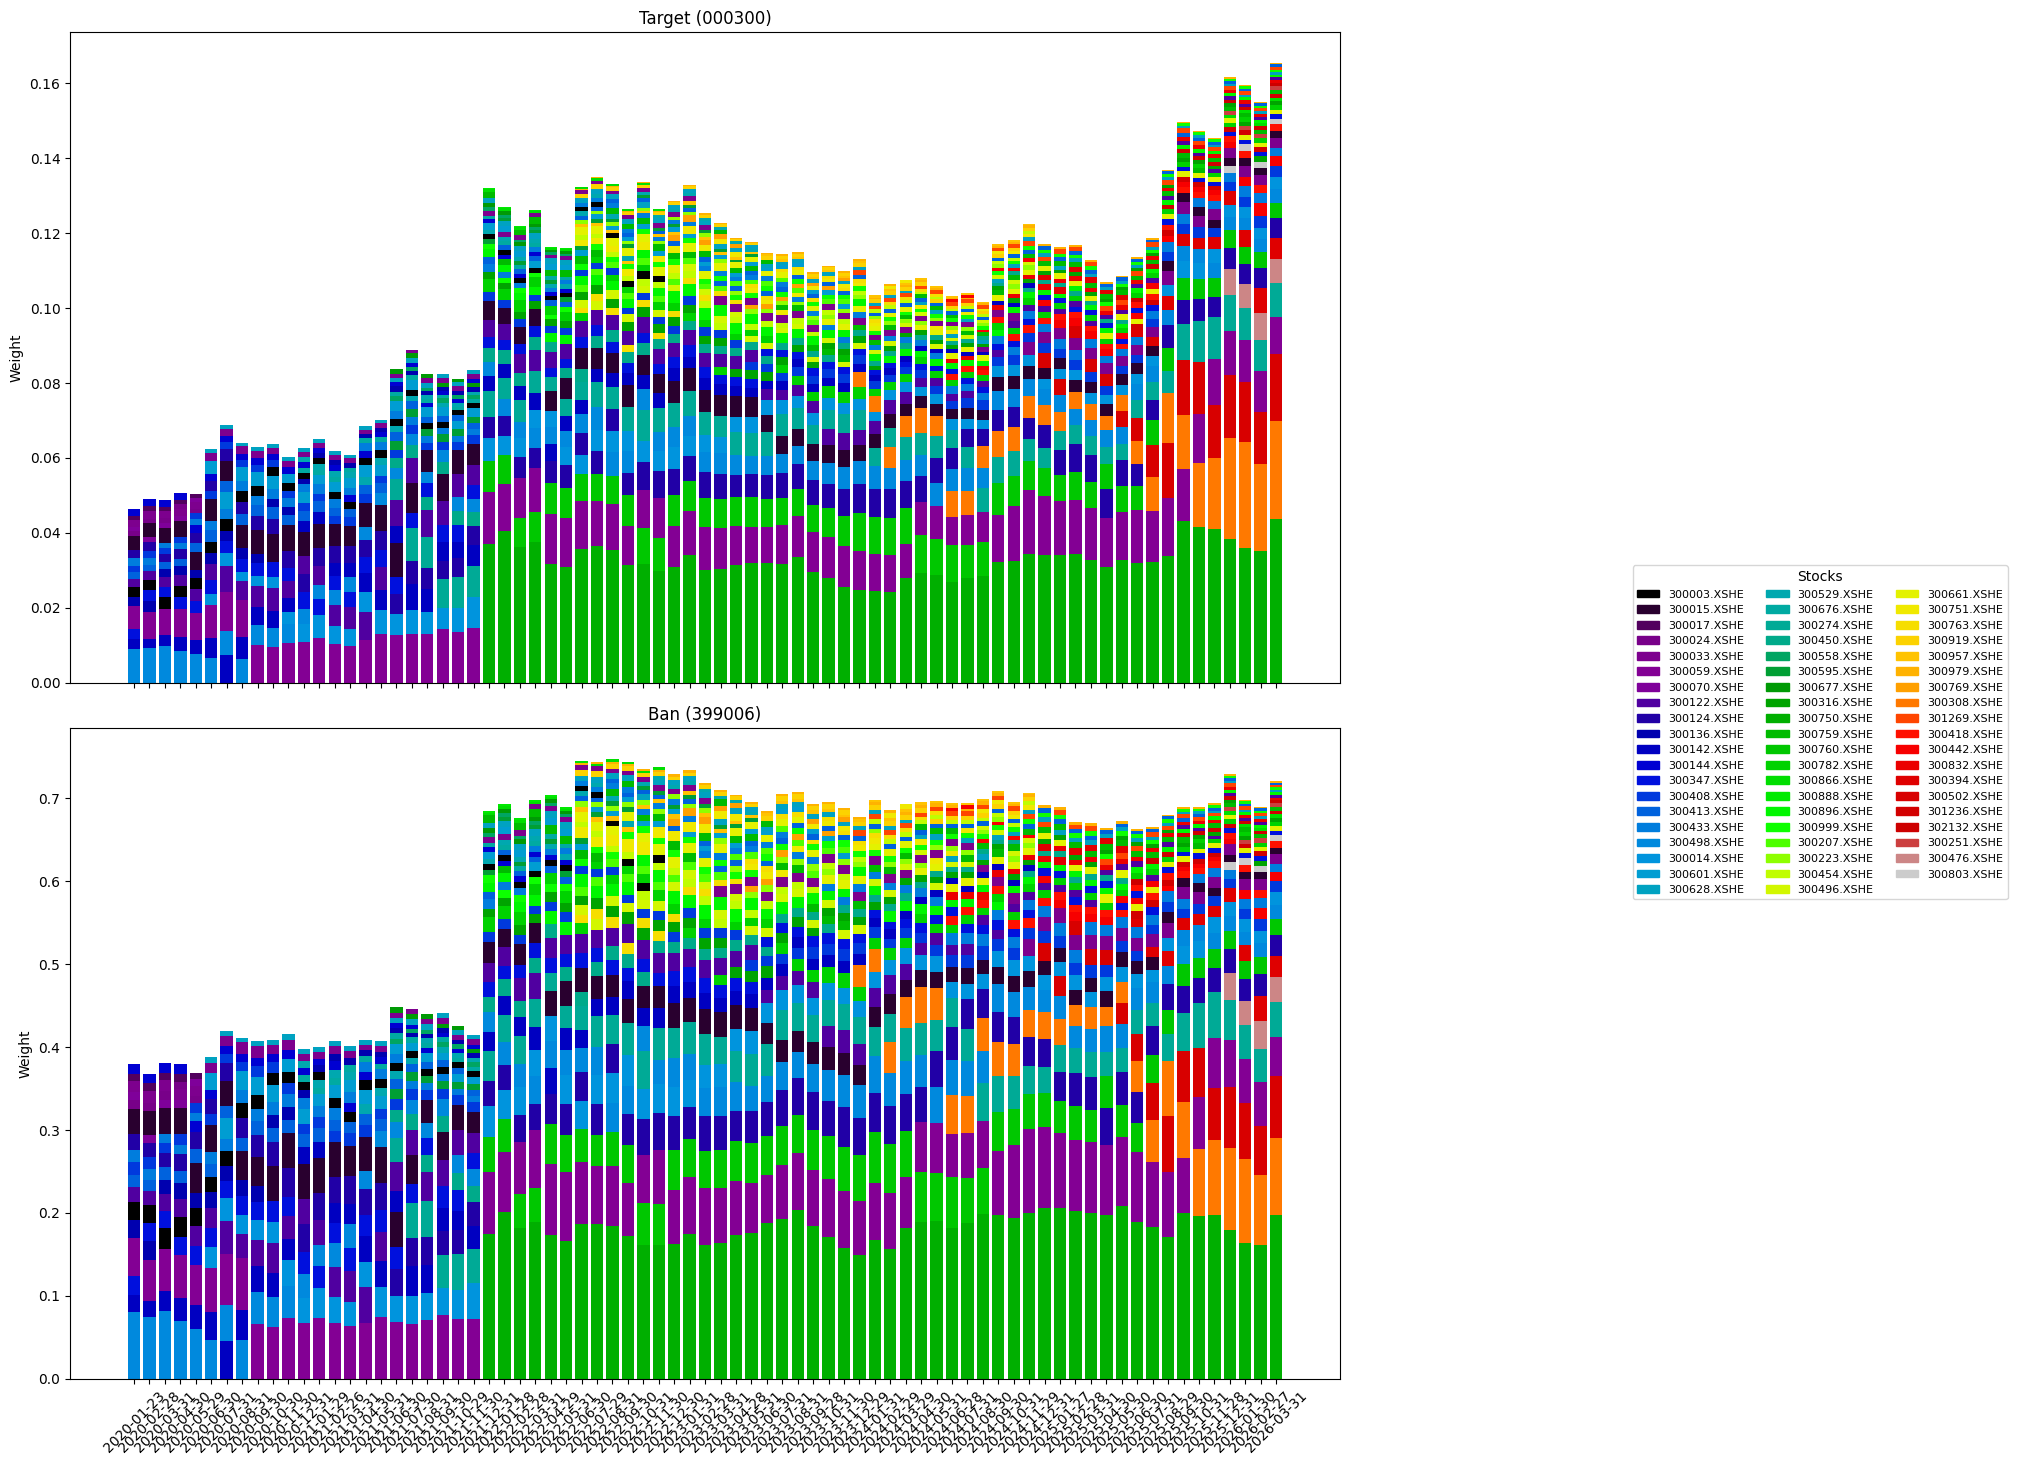

In [38]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math

dates = sorted(final_df['date'].unique())
all_stocks = final_df.index.unique().tolist()
n = len(all_stocks)
# ===== 颜色映射 =====
cmap = plt.cm.get_cmap('nipy_spectral', n)
color_map = {stock: cmap(i) for i, stock in enumerate(all_stocks)}

# ===== 自适应图高度 =====
n_stocks = len(all_stocks)
fig_height = max(6, n_stocks * 0.25)   # 关键：股票越多图越高

fig, axes = plt.subplots(2, 1, figsize=(16, fig_height), sharex=True)

titles = ['Target (000300)', 'Ban (399006)']
weight_cols = ['weight_x', 'weight_y']

for ax, title, col in zip(axes, titles, weight_cols):

    for i, dt in enumerate(dates):
        group = final_df[final_df['date'] == dt]
        group_sorted = group.sort_values('free_mkp', ascending=False)

        stocks = group_sorted.index.tolist()
        weights = group_sorted[col].values

        bottom = 0

        for j, stock in enumerate(stocks):
            ax.bar(
                i,
                weights[j],
                bottom=bottom,
                color=color_map[stock]
            )
            bottom += weights[j]

    ax.set_title(title)
    ax.set_ylabel("Weight")

# ===== x轴日期 =====
date_labels = [pd.to_datetime(d).strftime("%Y-%m-%d") for d in dates]
axes[-1].set_xticks(range(len(dates)))
axes[-1].set_xticklabels(date_labels, rotation=45)

# ===== legend 自适应列数 =====
ncol = math.ceil(n_stocks / 25)  # 每列最多25个

handles = [
    plt.Rectangle((0, 0), 1, 1, color=color_map[stock])
    for stock in all_stocks
]

fig.legend(
    handles,
    all_stocks,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    fontsize=8,
    ncol=ncol,
    title="Stocks"
)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # 给legend留空间
plt.show()

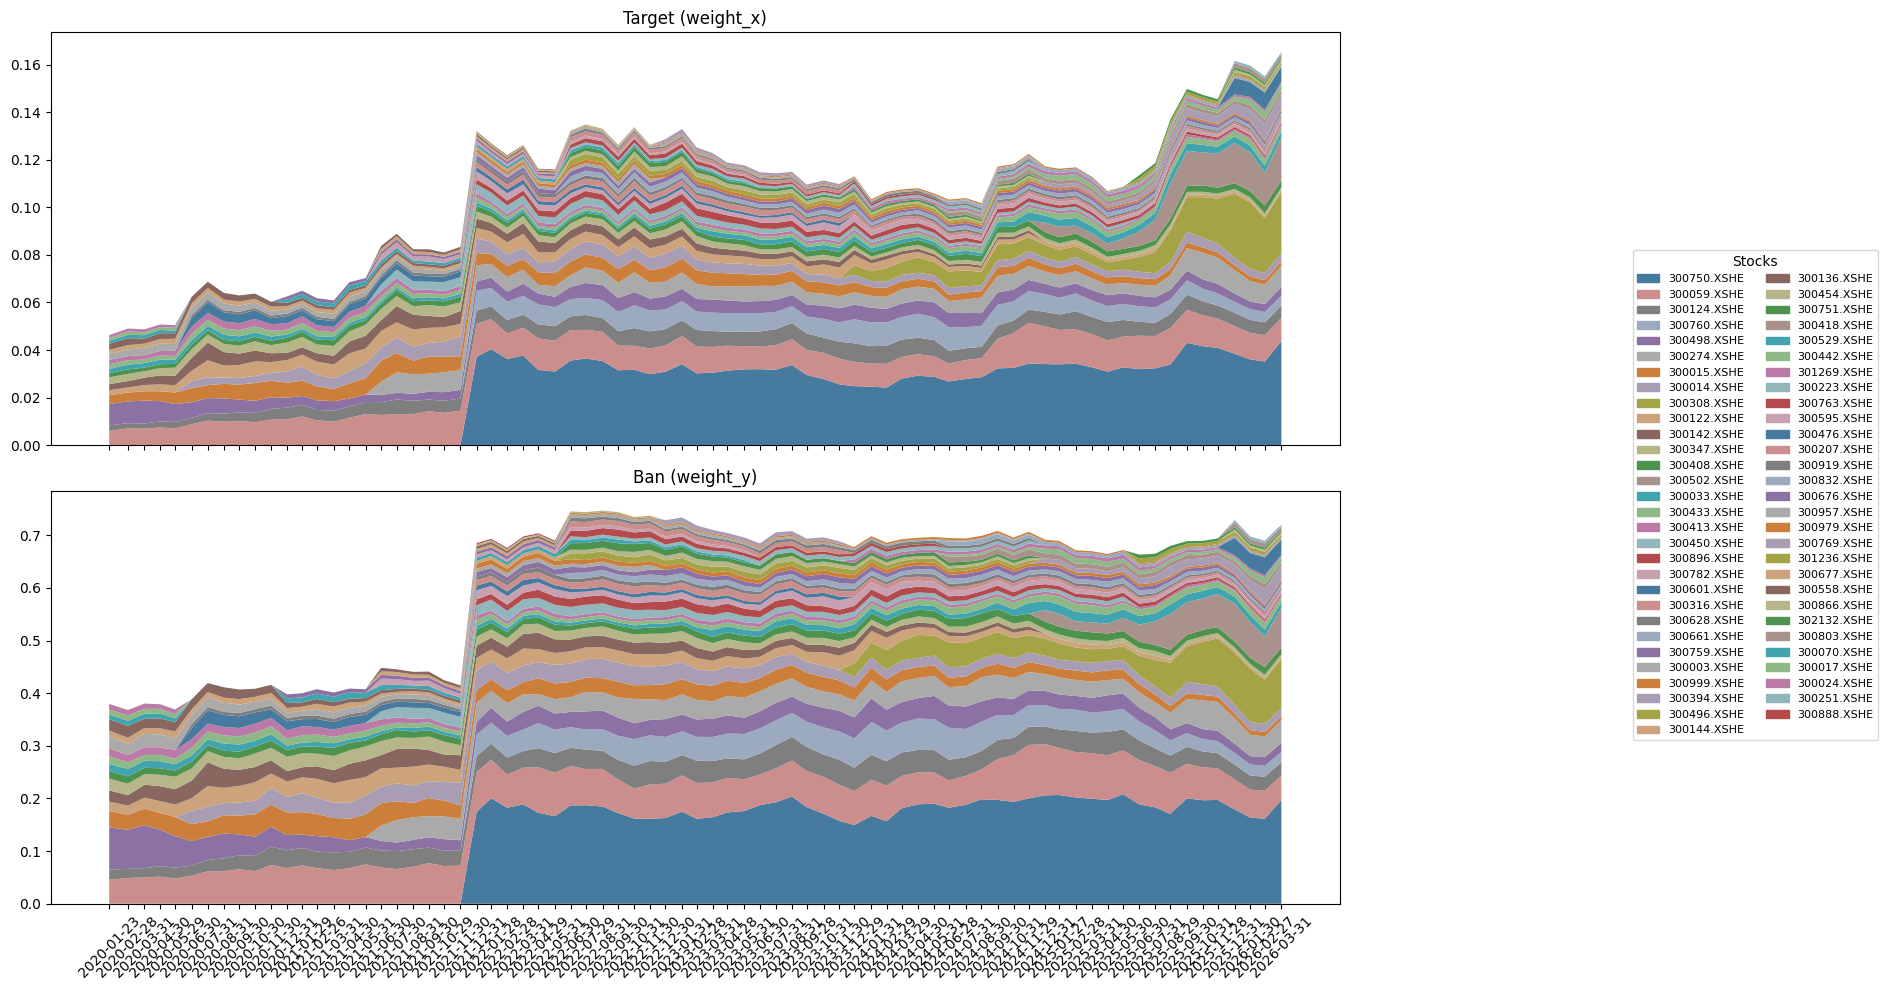

In [42]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = final_df.copy().reset_index()
df['date'] = pd.to_datetime(df['date'])

# ===== pivot =====
pivot_x = df.pivot_table(index='date', columns='order_book_id', values='weight_x', aggfunc='sum').fillna(0)
pivot_y = df.pivot_table(index='date', columns='order_book_id', values='weight_y', aggfunc='sum').fillna(0)

# ===== 排序（决定“从下到上”顺序）=====
order = pivot_x.mean().sort_values(ascending=False).index
pivot_x = pivot_x[order]
pivot_y = pivot_y[order]

dates = pivot_x.index
stocks = pivot_x.columns.tolist()
n = len(stocks)

# ===== 低饱和颜色（关键）=====
# 基础颜色池（低饱和）
base_colors = plt.cm.tab20(np.linspace(0, 1, 20))
# ===== 关键：跳跃式取色 =====
step = 7   # 可以调，比如 5 / 7 / 9
colors = [base_colors[(i * step) % 20] for i in range(n)]

# 降低饱和度（核心操作）
def desaturate(color, factor=0.6):
    r, g, b, a = color
    gray = 0.5
    r = r * factor + gray * (1 - factor)
    g = g * factor + gray * (1 - factor)
    b = b * factor + gray * (1 - factor)
    return (r, g, b, a)

colors = [desaturate(c, 0.6) for c in colors]

# ===== 画图 =====
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# --- weight_x ---
axes[0].stackplot(dates, pivot_x.T.values, colors=colors)
axes[0].set_title("Target (weight_x)")

# --- weight_y ---
axes[1].stackplot(dates, pivot_y.T.values, colors=colors)
axes[1].set_title("Ban (weight_y)")

# ===== x轴 =====
axes[1].set_xticks(dates)
axes[1].set_xticklabels([d.strftime("%Y-%m-%d") for d in dates], rotation=45)

# ===== legend（顺序 = 面积顺序）=====
handles = [
    plt.Rectangle((0, 0), 1, 1, color=colors[i])
    for i in range(n)
]

fig.legend(
    handles,
    stocks,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    fontsize=8,
    ncol=2,
    title="Stocks"
)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()